# --- SECCIÓN 1: SETUP ---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Imports OK")

Imports OK


In [3]:
PROCESSED_DIR = Path("../data/processed")

parquets = {
    "legitimate_modsec" : PROCESSED_DIR / "legitimate_modsec.parquet",
    "sqli_modsec"       : PROCESSED_DIR / "sqli_modsec.parquet",
    "owasp_inscope"     : PROCESSED_DIR / "owasp_inscope.parquet",
}

for name, path in parquets.items():
    exists = path.exists()
    print(f"{'OK' if exists else 'NO ENCONTRADO'}  {name}: {path}")

OK  legitimate_modsec: ..\data\processed\legitimate_modsec.parquet
OK  sqli_modsec: ..\data\processed\sqli_modsec.parquet
OK  owasp_inscope: ..\data\processed\owasp_inscope.parquet


# -- SECCIÓN 2: CARGA DE DATOS --

In [4]:
df_legit   = pd.read_parquet(parquets["legitimate_modsec"])
df_sqli    = pd.read_parquet(parquets["sqli_modsec"])
df_owasp   = pd.read_parquet(parquets["owasp_inscope"])

print(f"legitimate_modsec  -> {len(df_legit):,} filas  | columnas: {list(df_legit.columns)}")
print(f"sqli_modsec        -> {len(df_sqli):,} filas  | columnas: {list(df_sqli.columns)}")
print(f"owasp_inscope      -> {len(df_owasp):,} filas  | columnas: {list(df_owasp.columns)}")

legitimate_modsec  -> 69,101 filas  | columnas: ['payload', 'label', 'payload_len']
sqli_modsec        -> 30,544 filas  | columnas: ['payload', 'label', 'payload_len']
owasp_inscope      -> 4,793 filas  | columnas: ['timestamp', 'source_ip', 'method', 'path', 'query_string', 'status_code', 'label', 'rule_ids']


# --- SECCIÓN 3: NORMALIZACIÓN DE ESQUEMA ---

In [5]:
COLUMNS = ["payload", "label", "method", "path", "query_string", "status_code", "source"]

df_legit_norm = pd.DataFrame({
    "payload"      : df_legit["payload"],
    "label"        : df_legit["label"],
    "method"       : "UNKNOWN",
    "path"         : "UNKNOWN",
    "query_string" : df_legit["payload"],
    "status_code"  : None,
    "source"       : "modsec_learn",
})

df_sqli_norm = pd.DataFrame({
    "payload"      : df_sqli["payload"],
    "label"        : df_sqli["label"],
    "method"       : "UNKNOWN",
    "path"         : "UNKNOWN",
    "query_string" : df_sqli["payload"],
    "status_code"  : None,
    "source"       : "modsec_learn",
})

df_owasp_norm = pd.DataFrame({
    "payload"      : df_owasp["query_string"],
    "label"        : df_owasp["label"],
    "method"       : df_owasp["method"],
    "path"         : df_owasp["path"],
    "query_string" : df_owasp["query_string"],
    "status_code"  : df_owasp["status_code"],
    "source"       : "owasp_log",
})

for name, df in [("legitimate", df_legit_norm), ("sqli_modsec", df_sqli_norm), ("owasp", df_owasp_norm)]:
    print(f"{name:<15} -> columnas OK: {list(df.columns) == COLUMNS}")

legitimate      -> columnas OK: True
sqli_modsec     -> columnas OK: True
owasp           -> columnas OK: True


In [6]:
df_dataset = pd.concat([
    df_legit_norm,
    df_sqli_norm,
    df_owasp_norm,
], ignore_index=True)

print("=== Dataset parcial en memoria ===")
print(f"Total filas        : {len(df_dataset):,}")

print(f"\nDistribución de labels:")
print(df_dataset["label"].value_counts().to_string())

print(f"\nDistribución por fuente:")
print(df_dataset["source"].value_counts().to_string())

print(f"\nNulos por columna:")
print(df_dataset.isnull().sum().to_string())

=== Dataset parcial en memoria ===
Total filas        : 104,438

Distribución de labels:
label
legitimate     69101
sqli           34608
brute_force      469
xss              260

Distribución por fuente:
source
modsec_learn    99645
owasp_log        4793

Nulos por columna:
payload          3333
label               0
method              0
path                0
query_string     3333
status_code     99645
source              0


In [7]:
mask = df_dataset["payload"].isna()
df_dataset.loc[mask, "payload"]      = df_dataset.loc[mask, "path"]
df_dataset.loc[mask, "query_string"] = df_dataset.loc[mask, "path"]

print(f"Filas rellenadas con path : {mask.sum():,}")
print(f"Nulos restantes en payload: {df_dataset['payload'].isna().sum()}")
print(f"Nulos restantes en query_string: {df_dataset['query_string'].isna().sum()}")

print("\n=== Muestra de filas rellenadas ===")
print(df_dataset[mask][["payload","label","method","path","status_code"]].head(5).to_string())

Filas rellenadas con path : 3,333
Nulos restantes en payload: 0
Nulos restantes en query_string: 0

=== Muestra de filas rellenadas ===
                           payload        label method                         path status_code
99645                /wp-login.php  brute_force    GET                /wp-login.php         403
99646                            /  brute_force    GET                            /         404
99647  /d_d3f56ea6/d_54e455c7/x.js  brute_force    GET  /d_d3f56ea6/d_54e455c7/x.js         404
99648       /d_e1a6be30/d_81096e5d  brute_force    GET       /d_e1a6be30/d_81096e5d         404
99649                            /  brute_force    GET                            /         404


In [8]:
print(df_dataset.head(10))

                                                                                                                   payload  \
0  source%5Baction%5D=show&source%5Bapp%5D=Shopify&source%5Bcontroller%5D=checkouts%2Fweb%2Fcheckouts&source%5Bsection%...   
1                                                                                                             v=1645527473   
2  origin=onetag&domain=365mashbir.co.il&sn=ChromeSyncframe&so=3&topUrl=365mashbir.co.il&bundle=ldVXDl9hS0VDdENtdzZsT1V...   
3  random=1660540144644&cv=9&fst=1660539600000&num=1&bg=ffffff&guid=ON&eid=376635470&u_h=1080&u_w=1920&u_ah=1040&u_aw=1...   
4                                                                                                             v=1660480855   
5  uils=5cb004b2-38c9-4cda-874e-0c4f6d85d4a2-tuct9f35a3a&eflp=6d49520254708dce6cd8831ff1bb12e17c3386a0f81457f202bd30209...   
6  $req=Ch0KDGdvb2dsZWNocm9tZRINMTA0LjAuNTExMi44MRIbCg0IBRAGGAEiAzAwMTABENajDhoCGAZLRKOxEhsKDQgBEAYYASIDMDAxMAEQrfsKGg

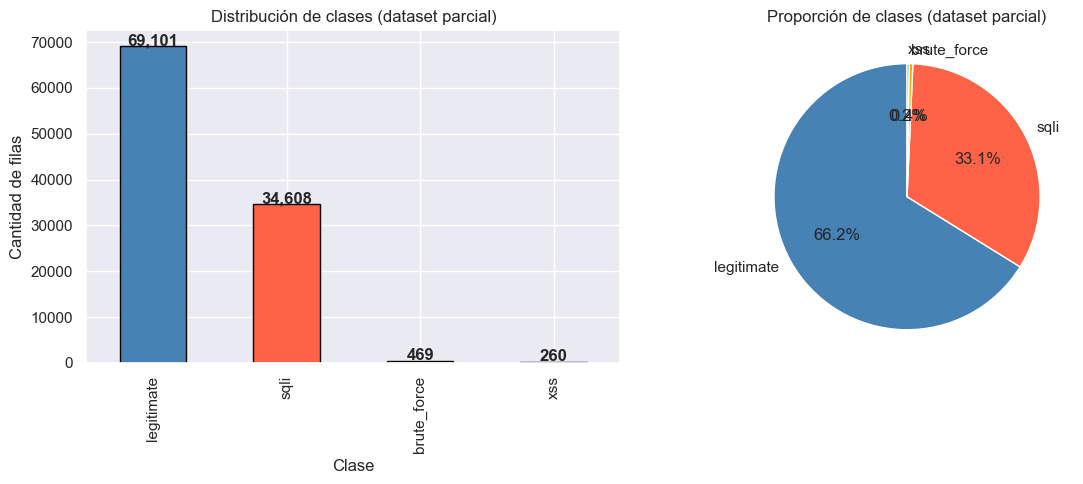


Clases pendientes : ddos, brute_force
Filas actuales    : 104,438
Filas objetivo    : 100,000+
Estado            : EN CONSTRUCCIÓN, esperando datasets sintéticos


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_dataset["label"].value_counts()
counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato", "orange"], edgecolor="black")
axes[0].set_title("Distribución de clases (dataset parcial)")
axes[0].set_ylabel("Cantidad de filas")
axes[0].set_xlabel("Clase")
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato", "orange"], startangle=90)
axes[1].set_title("Proporción de clases (dataset parcial)")

plt.tight_layout()
plt.show()

print(f"\nClases pendientes : ddos, brute_force")
print(f"Filas actuales    : {len(df_dataset):,}")
print(f"Filas objetivo    : 100,000+")
print(f"Estado            : EN CONSTRUCCIÓN, esperando datasets sintéticos")